# PROTOCOL: 4-Channel Architecture (Divide et Impera)
- **4-Channel Input:** Standard RGB images + **Stain-Normalized Hematoxylin Channel (TIFF)** (via Macenko method) to explicitly feed nuclear structure to the model.
- **High-Resolution Patching:** Eliminates resizing artifacts.
    - Training uses random **$512 \times 512$ crops** from original resolution images
    - Guided by **Otsu Thresholding** to ensure tissue presence.
- **Modern Optimization:** Uses **Lion Optimizer** ($LR=5e^{-5}$) with Cosine Annealing and **MixUp Augmentation** for robust convergence.
- **Robust Inference Strategy (Divide et Impera)**
    - **Phase 1: Deep Learning Vision (ConvNeXt-Tiny):** 5-Fold Stratified CV ensemble.
    - **Phase 2: Robust Aggregation (Positivity Indices):** 
        - Instead of simple averaging, computes **Meta-Features** (Mean, Max, Std, Positivity Rate) from the tile probabilities.
        - **Logistic Regression** meta-classifier makes the final diagnosis, filtering out noise from healthy tissue tiles.
- **Oracle Mode:** Localization regressors are dropped in favor of ground-truth masks for deterministic cropping.

In [1]:
# ============================================================
# 1. Imports and Configuration
# ============================================================
import os
import random
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
import tifffile as tiff

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
sns.set(font_scale=1.2)
sns.set_style("whitegrid")

class Config:
    SEED = 42
    
    # --- PATHS (Update these to your Kaggle environment) ---
    # CLEAN_IMG_DIR: Processed training images (Goo removed)
    CLEAN_IMG_DIR = '/kaggle/input/dataset/train_data_cleaned/images'
    CLEAN_MASK_DIR = '/kaggle/input/dataset/train_data_cleaned/masks'
    CLEAN_LABELS  = '/kaggle/input/dataset/train_data_cleaned/train_labels.csv'
    
    # TIFF_DIR: Macenko-Normalized Hematoxylin Channels (Masked)
    TRAIN_TIFF_DIR = '/kaggle/input/tiff-images/train' 
    TEST_TIFF_DIR = '/kaggle/input/tiff-images/test' 
    
    # TEST PATHS
    TEST_IMG_DIR = '/kaggle/input/dataset/test_data/images'
    TEST_MASK_DIR = '/kaggle/input/dataset/test_data/masks'

    # --- HYPERPARAMS ---
    IMG_SIZE_CLS = 512   # High-Res Patch Size
    STRIDE = 256         # Overlap for Inference Tiling
    BATCH_SIZE = 16      
    NUM_CLASSES = 4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # OPTIMIZATION
    EPOCHS_CLS = 50      
    ACCUM_STEPS = 2      
    LR_CLS = 5e-5        # Low LR for Lion
    WD_CLS = 1e-2        # High Decay for Lion
    K_FOLDS = 5

    # Choose ONE of: "effnetv2_s", "resnet50", "regnety_16gf", "vit_b16", "convnext_tiny"
    MODEL_NAME = "resnet50"

    
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    
set_seed(Config.SEED)
print(f"Operational Device: {Config.DEVICE}")

# ============================================================
# 2. Utilities & Optimizers
# ============================================================

class Lion(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        if not 0.0 <= lr: 
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= betas[0] < 1.0: 
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0: 
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: 
                    continue
                p.data.mul_(1 - group['lr'] * group['weight_decay'])
                grad = p.grad
                state = self.state[p]
                if len(state) == 0: 
                    state['exp_avg'] = torch.zeros_like(p)
                exp_avg = state['exp_avg']
                beta1, beta2 = group['betas']
                update = exp_avg * beta1 + grad * (1 - beta1)
                p.add_(torch.sign(update), alpha=-group['lr'])
                exp_avg.mul_(beta2).add_(grad, alpha=1 - beta2)
        return loss

class EarlyStopping:
    def __init__(self, patience=7, mode="max", verbose=False, delta=0, path='checkpoint.pth', trace_func=print):
        self.patience = patience
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_metric, model):
        score = val_metric
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_metric, model)
            return

        improved = False
        if self.mode == "min":
            if score < (self.best_score - self.delta): 
                improved = True
        elif self.mode == "max":
            if score > (self.best_score + self.delta): 
                improved = True
        
        if improved:
            self.best_score = score
            self.save_checkpoint(val_metric, model)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: 
                self.early_stop = True

    def save_checkpoint(self, val_metric, model):
        if self.verbose: 
            self.trace_func(f'   ✅ Improved ({self.best_score:.4f}). Saving...')
        torch.save(model.state_dict(), self.path)

# Helper: Mixup
def mixup_data(x, y, alpha=0.4):
    if alpha > 0: 
        lam = np.random.beta(alpha, alpha)
    else: 
        lam = 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(Config.DEVICE)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def get_bbox_from_mask(mask_np):
    """Returns (x1, y1, x2, y2) from a binary mask."""
    rows = np.any(mask_np, axis=1)
    cols = np.any(mask_np, axis=0)
    if not np.any(rows) or not np.any(cols): 
        return None
    ymin, ymax = np.where(rows)[0][[0, -1]]
    xmin, xmax = np.where(cols)[0][[0, -1]]
    return xmin, ymin, xmax, ymax

Operational Device: cuda


In [2]:
# ============================================================
# 3. Dataset (Mosaic & Smart Patching)
# ============================================================
class MosaicDataset(Dataset):
    def __init__(self, df, img_dir, mask_dir, tiff_dir, transform=None, mode='train', 
                 patches_per_image=1, cache_data=True):
        self.df = df
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.tiff_dir = tiff_dir
        self.mode = mode
        self.patches_per_image = patches_per_image 
        self.le = LabelEncoder()
        
        self.cache = []
        if 'label' in self.df.columns:
            self.df['encoded_label'] = self.le.fit_transform(self.df['label'])
            
        if cache_data:
            print(f"   Pre-loading {len(df)} images...")
            for idx in tqdm(range(len(df)), desc="Caching"):
                self.cache.append(self.load_item(idx))

    def __len__(self):
        return len(self.df) * self.patches_per_image

    def load_item(self, idx):
        row = self.df.iloc[idx]
        fname = row['sample_index']
        
        # Load RGB
        img_path = os.path.join(self.img_dir, fname)
        rgb = cv2.imread(img_path)
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        
        # Load TIFF
        tiff_name = fname.replace(".png", ".tif")
        tiff_path = os.path.join(self.tiff_dir, tiff_name)
        if os.path.exists(tiff_path):
            tif = tiff.imread(tiff_path)
        else:
            tif = np.zeros(rgb.shape[:2], dtype=np.uint8)
            
        if tif.ndim == 2: tif = np.expand_dims(tif, axis=-1)
        
        # Load Mask (Tissue Guidance)
        # Try both naming conventions
        mask_name = fname.replace("img_", "mask_")
        
        mask_path = None
        if os.path.exists(os.path.join(self.mask_dir, mask_name)):
            mask_path = os.path.join(self.mask_dir, mask_name)
            
        if mask_path:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            # Fallback: Otsu
            hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
            _, mask = cv2.threshold(hsv[:,:,1], 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

        label = row['encoded_label'] if 'encoded_label' in row else -1
        return rgb, tif, mask, label

    def get_tissue_guided_crop(self, rgb, tif, mask, crop_size=512):
        h, w = rgb.shape[:2]
        
        # Pad if needed
        if h < crop_size or w < crop_size:
            pad_h = (crop_size - h % crop_size) % crop_size
            pad_w = (crop_size - w % crop_size) % crop_size
            rgb = np.pad(rgb, ((0, pad_h), (0, pad_w), (0, 0)))
            tif = np.pad(tif, ((0, pad_h), (0, pad_w), (0, 0)))
            mask = np.pad(mask, ((0, pad_h), (0, pad_w)))
            h, w = rgb.shape[:2]

        # Smart Sampling: Try 10 times to find a "Good" patch (>30% tissue)
        for _ in range(10):
            y = random.randint(0, h - crop_size)
            x = random.randint(0, w - crop_size)
            
            mask_crop = mask[y:y+crop_size, x:x+crop_size]
            tissue_ratio = np.count_nonzero(mask_crop) / (crop_size * crop_size)
            
            if tissue_ratio > 0.30: 
                return rgb[y:y+crop_size, x:x+crop_size], tif[y:y+crop_size, x:x+crop_size]
        
        # Fallback: Center crop
        cy, cx = h//2, w//2
        y, x = max(0, cy-crop_size//2), max(0, cx-crop_size//2)
        return rgb[y:y+crop_size, x:x+crop_size], tif[y:y+crop_size, x:x+crop_size]

    def __getitem__(self, idx):
        real_idx = idx % len(self.df)
        
        if self.cache:
            rgb, tif, mask, label = self.cache[real_idx]
        else:
            rgb, tif, mask, label = self.load_item(real_idx)
            
        # Crop (Random or Center)
        # Note: Validation also uses this crop to get High-Res input
        rgb_patch, tif_patch = self.get_tissue_guided_crop(rgb, tif, mask, Config.IMG_SIZE_CLS)
        
        rgb_t = TF.to_tensor(rgb_patch)
        tif_t = TF.to_tensor(tif_patch)
        full_t = torch.cat([rgb_t, tif_t], dim=0)

        if self.mode == 'train':
            # Geometry
            if random.random() > 0.5: full_t = TF.hflip(full_t)
            if random.random() > 0.5: full_t = TF.vflip(full_t)
            if random.random() > 0.5: 
                angle = random.choice([90, 180, 270])
                full_t = TF.rotate(full_t, angle)
            
            # Stain Jitter (Approx)
            if random.random() > 0.2:
                # Scale RGB brightness/contrast
                full_t[:3] = TF.adjust_brightness(full_t[:3], 1 + (random.random()*0.4 - 0.2))
                full_t[:3] = TF.adjust_contrast(full_t[:3], 1 + (random.random()*0.4 - 0.2))
                
                # Scale H-Channel (TIFF)
                stain_factor = 1.0 + (random.random() * 0.4 - 0.2) 
                full_t[3] = full_t[3] * stain_factor
                
                full_t = torch.clamp(full_t, 0, 1)
            
            # Random Erasing
            if random.random() > 0.3:
                transforms.RandomErasing(p=1.0, scale=(0.02, 0.15))(full_t)

        # Normalize
        mean = [0.485, 0.456, 0.406, 0.5]
        std  = [0.229, 0.224, 0.225, 0.5]
        full_t = TF.normalize(full_t, mean=mean, std=std)
        
        return full_t, label


In [3]:
# ============================================================
# 4. Model Definition (Multi-Architecture)
# ============================================================
def get_classifier_model(num_classes):
    name = Config.MODEL_NAME.lower()
    print(f"   Instantiating {name} (4-Channel)...")

    # 1. Instantiate Backbone
    if name == "convnext_tiny": 
        model = models.convnext_tiny(weights='IMAGENET1K_V1')
        first_layer = model.features[0][0]
        # Head access via string name for generic handling later
        head_layer_name = 'classifier.2' 
        
    elif name == "effnetv2_s":
        model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
        first_layer = model.features[0][0]
        head_layer_name = 'classifier.1' # EfficientNetV2 usually uses classifier[1] as Linear

    elif name == "resnet50":
        model = models.resnet50(weights='IMAGENET1K_V1')
        first_layer = model.conv1
        head_layer_name = 'fc'

    elif name == "regnety_16gf":
        model = models.regnet_y_16gf(weights='IMAGENET1K_V1')
        first_layer = model.stem[0]
        head_layer_name = 'fc'

    elif name == "vit_b16":
        model = models.vit_b_16(weights='IMAGENET1K_V1')
        first_layer = model.conv_proj
        head_layer_name = 'heads.head'

    else:
        raise ValueError(f"Unknown model type: {Config.MODEL_NAME}")

    # 2. Surgical Modification (3 -> 4 Channels)
    # We apply this logic generically to whatever 'first_layer' we identified
    old_conv = first_layer
    
    # Check if bias exists (some layers like ResNet conv1 don't have bias)
    has_bias = old_conv.bias is not None
    
    new_conv = nn.Conv2d(
        in_channels=4, 
        out_channels=old_conv.out_channels, 
        kernel_size=old_conv.kernel_size, 
        stride=old_conv.stride, 
        padding=old_conv.padding, 
        bias=has_bias
    )
    
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:4] = torch.mean(old_conv.weight, dim=1, keepdim=True)
        if has_bias:
            new_conv.bias = nn.Parameter(old_conv.bias.clone())

    # Replace the layer in the model
    # We need to find the parent module to set the attribute
    if name == "convnext_tiny": model.features[0][0] = new_conv
    elif name == "effnetv2_s": model.features[0][0] = new_conv
    elif name == "resnet50": model.conv1 = new_conv
    elif name == "regnety_16gf": model.stem[0] = new_conv
    elif name == "vit_b16": model.conv_proj = new_conv

    # 3. Modify Head
    # We navigate to the head layer using the string name
    parts = head_layer_name.split('.')
    parent = model
    for part in parts[:-1]:
        if part.isdigit(): parent = parent[int(part)]
        else: parent = getattr(parent, part)
        
    last_layer_name = parts[-1]
    if last_layer_name.isdigit():
        old_fc = parent[int(last_layer_name)]
        parent[int(last_layer_name)] = nn.Linear(old_fc.in_features, num_classes)
    else:
        old_fc = getattr(parent, last_layer_name)
        setattr(parent, last_layer_name, nn.Linear(old_fc.in_features, num_classes))
    
    return model.to(Config.DEVICE)

In [4]:
# ============================================================
# 5. Training Loop (Phase 1)
# ============================================================
def train_classifier_kfold(df):
    print(f"\nPHASE 1: Deep Learning Training ({Config.K_FOLDS}-Fold CV)...")
    
    skf = StratifiedKFold(n_splits=Config.K_FOLDS, shuffle=True, random_state=Config.SEED)
    le = LabelEncoder()
    df['encoded_label'] = le.fit_transform(df['label'])
    
    fold_histories = []
    oof_preds = []    
    oof_targets = []  
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['encoded_label'])):
        print(f"\nSTARTING FOLD {fold+1}/{Config.K_FOLDS}")
        
        train_df = df.iloc[train_idx].copy()
        val_df = df.iloc[val_idx].copy()
        
        # Datasets
        train_ds = MosaicDataset(train_df, Config.CLEAN_IMG_DIR, Config.CLEAN_MASK_DIR, Config.TRAIN_TIFF_DIR, mode='train', patches_per_image=4, cache_data=True)
        val_ds   = MosaicDataset(val_df,   Config.CLEAN_IMG_DIR, Config.CLEAN_MASK_DIR, Config.TRAIN_TIFF_DIR, mode='val', patches_per_image=1, cache_data=True)
        
        train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=4, persistent_workers=True, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)
        
        model = get_classifier_model(Config.NUM_CLASSES)
        
        # Weights & Loss
        all_labels = train_df['encoded_label'].values
        class_weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(Config.DEVICE)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
        scaler = torch.cuda.amp.GradScaler()

        # Identify Head Params for Warmup
        name = Config.MODEL_NAME.lower()
        if name == "convnext_tiny": 
            head_params = model.classifier[2].parameters()
        elif name == "effnetv2_s": 
            head_params = model.classifier[-1].parameters()
        elif name == "resnet50": 
            head_params = model.fc.parameters()
        elif name == "regnety_16gf": 
            head_params = model.fc.parameters()
        elif name == "vit_b16": 
            head_params = model.heads.head.parameters()
        
        # Identify First Layer Params
        if name == "convnext_tiny": 
            first_layer_params = model.features[0][0].parameters()
        elif name == "effnetv2_s": 
            first_layer_params = model.features[0][0].parameters()
        elif name == "resnet50": 
            first_layer_params = model.conv1.parameters()
        elif name == "regnety_16gf": 
            first_layer_params = model.stem[0].parameters()
        elif name == "vit_b16": 
            first_layer_params = model.conv_proj.parameters()

        # --- WARMUP (Sandwich) ---
        print(f"   Fold {fold+1}: Warming up...")
        for param in model.parameters(): param.requires_grad = False
        for param in first_layer_params: param.requires_grad = True
        for param in head_params: param.requires_grad = True
            
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
        
        model.train()
        for epoch in range(5): 
            for i, (imgs, lbls) in enumerate(train_loader):
                imgs, lbls = imgs.to(Config.DEVICE), lbls.to(Config.DEVICE)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    out = model(imgs)
                    loss = criterion(out, lbls) / Config.ACCUM_STEPS
                scaler.scale(loss).backward()
                if (i+1) % Config.ACCUM_STEPS == 0:
                    scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
        print("   ✅ Warmup Complete.")

        # --- FULL TRAINING (Lion) ---
        print(f"   Fold {fold+1}: Full Training...")
        for param in model.parameters(): param.requires_grad = True
        
        optimizer = Lion(model.parameters(), lr=Config.LR_CLS, weight_decay=Config.WD_CLS)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS_CLS, eta_min=1e-6)
        
        model_path = f"classifier_fold{fold}.pth"
        early_stopping = EarlyStopping(patience=15, mode="max", verbose=False, path=model_path)
        
        # Updated History Dict with Train F1
        history = {
            'train_loss':[], 
            'train_acc':[], 
            'train_f1':[], 
            'val_loss':[], 
            'val_acc':[], 
            'val_f1':[]
        }
        
        for epoch in range(Config.EPOCHS_CLS):
            model.train()
            t_loss_sum, t_total, t_corr = 0, 0, 0
            optimizer.zero_grad()
            
            for i, (imgs, lbls) in enumerate(tqdm(train_loader, desc=f"F{fold+1} Ep{epoch+1}", leave=False)):
                imgs, lbls = imgs.to(Config.DEVICE), lbls.to(Config.DEVICE)
                
                # Mixup
                if random.random() < 0.5:
                    imgs, lbls_a, lbls_b, lam = mixup_data(imgs, lbls)
                    with torch.cuda.amp.autocast():
                        out = model(imgs)
                        loss = mixup_criterion(criterion, out, lbls_a, lbls_b, lam)
                        loss = loss / Config.ACCUM_STEPS
                else:
                    with torch.cuda.amp.autocast():
                        out = model(imgs)
                        loss = criterion(out, lbls)
                        loss = loss / Config.ACCUM_STEPS
                
                scaler.scale(loss).backward()
                
                if (i+1) % Config.ACCUM_STEPS == 0:
                    scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
                
                t_loss_sum += loss.item() * Config.ACCUM_STEPS * imgs.size(0)
                _, preds = torch.max(out, 1) 
                t_corr += (preds == lbls).sum().item()
                t_total += lbls.size(0)
            
            scheduler.step()
            
            # --- CALC TRAIN F1 (Extra Pass) ---
            # To get accurate Train F1 without mixup noise
            train_preds_epoch = []
            train_labels_epoch = []
            model.eval() # Temp eval mode for clean inference
            with torch.no_grad():
                # We iterate a subset or full train_loader. Full is safer for accuracy.
                # If too slow, sample 20%. Here we do full for correctness.
                for imgs, lbls in train_loader:
                    imgs = imgs.to(Config.DEVICE)
                    out = model(imgs)
                    preds = torch.argmax(out, dim=1)
                    train_preds_epoch.extend(preds.cpu().numpy())
                    train_labels_epoch.extend(lbls.cpu().numpy())
            
            t_f1 = f1_score(train_labels_epoch, train_preds_epoch, average='macro')
            model.train() # Switch back
            
            # --- VALIDATION ---
            model.eval()
            v_loss_sum, v_total, v_corr = 0, 0, 0
            all_preds, all_labels_val = [], []
            
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs, lbls = imgs.to(Config.DEVICE), lbls.to(Config.DEVICE)
                    out = model(imgs)
                    loss = criterion(out, lbls)
                    
                    v_loss_sum += loss.item() * imgs.size(0)
                    _, preds = torch.max(out, 1)
                    v_corr += (preds == lbls).sum().item()
                    v_total += lbls.size(0)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels_val.extend(lbls.cpu().numpy())
            
            # Metrics
            t_loss = t_loss_sum / t_total; t_acc = t_corr / t_total
            v_loss = v_loss_sum / v_total; v_acc = v_corr / v_total
            v_f1 = f1_score(all_labels_val, all_preds, average='macro')
            
            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['train_f1'].append(t_f1)
            history['val_loss'].append(v_loss)
            history['val_acc'].append(v_acc)
            history['val_f1'].append(v_f1)
            
            print(
                f"   Ep {epoch+1:3d}/{Config.EPOCHS_CLS}: "
                f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.4f} | Train F1: {t_f1:.4f} | "
                f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f} | Val F1: {v_f1:.4f}"
            )
            
            early_stopping(v_f1, model)
            if early_stopping.early_stop:
                print(f"   Fold {fold+1} Converged.")
                break
        
        fold_histories.append(history)
        
        # OOF Generation
        print(f"   📊 Generating OOF Data for Fold {fold+1}...")
        model.load_state_dict(torch.load(model_path))
        model.eval()
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(Config.DEVICE), lbls.to(Config.DEVICE)
                out = model(imgs)
                _, preds = torch.max(out, 1)
                oof_preds.extend(preds.cpu().numpy())
                oof_targets.extend(lbls.cpu().numpy())
                
        del model, optimizer, scaler, train_loader, val_loader
        torch.cuda.empty_cache()

    oof_f1 = f1_score(oof_targets, oof_preds, average='macro')
    print(f"\n✅ CV Complete. Overall OOF F1: {oof_f1:.4f}")
    return le, fold_histories, oof_f1, oof_targets, oof_preds

In [5]:
# ============================================================
# 6. Phase 2 Helpers: Feature Extraction & Robust Aggregation
# ============================================================
def extract_tile_predictions(model, img_paths, tiff_dir, crop_size=512, stride=256):
    """Scans slides and returns PROBABILITIES for every tile."""
    print(f"   🔮 Extracting Tile Probabilities from {len(img_paths)} slides...")
    model.eval()
    slide_preds = {}
    mean_4ch = [0.485, 0.456, 0.406, 0.5]
    std_4ch  = [0.229, 0.224, 0.225, 0.5]

    for fname in tqdm(img_paths, desc="Tile Inference"):
        rgb = cv2.imread(fname)
        if rgb is None: continue
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        
        base_name = os.path.basename(fname)
        tiff_name = base_name.replace(".png", ".tif")
        tiff_path = os.path.join(tiff_dir, tiff_name)
        
        if os.path.exists(tiff_path):
            try:
                t = tiff.imread(tiff_path)
                if t.dtype != np.uint8: t = (t / t.max() * 255).astype(np.uint8)
            except: t = np.zeros(rgb.shape[:2], dtype=np.uint8)
        else: t = np.zeros(rgb.shape[:2], dtype=np.uint8)
            
        if t.ndim == 2: t = np.expand_dims(t, axis=-1)
        full_img = np.concatenate([rgb, t], axis=-1)
        
        h, w = full_img.shape[:2]
        pad_h = (crop_size - h % crop_size) % crop_size
        pad_w = (crop_size - w % crop_size) % crop_size
        if pad_h > 0 or pad_w > 0:
            full_img = np.pad(full_img, ((0, pad_h), (0, pad_w), (0, 0)))
            h, w = full_img.shape[:2]
            
        patches = []
        for y in range(0, h - crop_size + 1, stride):
            for x in range(0, w - crop_size + 1, stride):
                patch = full_img[y:y+crop_size, x:x+crop_size, :]
                p_t = TF.to_tensor(patch)
                p_t = TF.normalize(p_t, mean=mean_4ch, std=std_4ch)
                patches.append(p_t)
        
        if len(patches) == 0: continue
        
        tile_probs = []
        with torch.no_grad():
            for i in range(0, len(patches), 32):
                batch = torch.stack(patches[i:i+32]).to(Config.DEVICE)
                logits = model(batch)
                probs = F.softmax(logits, dim=1)
                tile_probs.append(probs.cpu().numpy())
                
        slide_preds[base_name] = np.concatenate(tile_probs, axis=0)
            
    return slide_preds

def compute_meta_features(slide_preds_dict, file_list):
    """Converts tile probabilities into Positivity Indices (P1, P2, P3)."""
    print("   📊 Computing Meta-Features (Positivity Indices)...")
    features = []
    valid_files = []
    
    for fname in file_list:
        fname = os.path.basename(fname)
        if fname not in slide_preds_dict: continue
        probs = slide_preds_dict[fname] # (N_tiles, 4)
        
        # Positivity Indices
        f_mean = np.mean(probs, axis=0)
        f_max = np.max(probs, axis=0)
        f_std = np.std(probs, axis=0)
        f_pos = np.mean(probs > 0.5, axis=0)
        k = max(1, int(len(probs) * 0.10))
        f_topk = np.sort(probs, axis=0)[-k:].mean(axis=0)

        # 20 Features Total
        row = np.concatenate([f_mean, f_max, f_std, f_pos, f_topk])
        features.append(row)
        valid_files.append(fname)
        
    return np.array(features), valid_files

def train_robust_aggregator(X_train, y_train, X_test, n_folds=5):
    print(f"\n🧠 Training Robust Aggregator (LogisticRegression)...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 4))
    test_preds = np.zeros((len(X_test), 4))
    
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=0.5, max_iter=1000)
        clf.fit(X_train[train_idx], y_train[train_idx])
        
        val_probs = clf.predict_proba(X_train[val_idx])
        oof_preds[val_idx] = val_probs
        
        test_probs = clf.predict_proba(X_test)
        test_preds += test_probs / n_folds
        
        val_labels = np.argmax(val_probs, axis=1)
        f1 = f1_score(y_train[val_idx], val_labels, average='macro')
        f1_scores.append(f1)
        print(f"   Fold {fold+1} F1: {f1:.4f}")
        
    avg_f1 = np.mean(f1_scores)
    print(f"✅ Robust CV Complete. Avg F1: {avg_f1:.4f}")
    return oof_preds, test_preds, avg_f1


In [10]:
# ============================================================
# 7. Visualization
# ============================================================
def plot_history_cls(fold_histories, title_suffix=""):
    print(f"\n📊 Plotting History for {len(fold_histories)} Folds...")
    
    # 4 metrics: Loss, Accuracy, Train F1, Val F1
    fig, axes = plt.subplots(1, 4, figsize=(26, 5))
    metrics = [
        ('train_loss', 'val_loss', 'Loss', 'blue', 'red'), 
        ('train_acc', 'val_acc', 'Accuracy', 'blue', 'red'), 
        ('train_f1', 'train_f1', 'Train F1', 'purple', 'purple'), # Compare Train vs Train
        ('val_f1', 'val_f1', 'Validation F1', 'green', 'green')
    ]
    
    for i, (tm, vm, title, c_train, c_val) in enumerate(metrics):
        ax = axes[i]
        max_len = max(len(h[vm]) for h in fold_histories)
        
        # Plot individual folds
        for h in fold_histories:
            if tm in h: ax.plot(h[tm], color=c_train, alpha=0.1)
            if vm in h and tm != vm: ax.plot(h[vm], color=c_val, alpha=0.1)
            elif vm in h and tm == vm: ax.plot(h[vm], color=c_val, alpha=0.1)
            
        # Plot Mean
        # Pad data with NaNs for mean calculation
        if tm in fold_histories[0]:
            data_t = np.array([h[tm] + [np.nan]*(max_len-len(h[tm])) for h in fold_histories])
            ax.plot(np.nanmean(data_t, axis=0), color=c_train, label='Mean Train', linewidth=2)
            
        if vm in fold_histories[0] and tm != vm:
            data_v = np.array([h[vm] + [np.nan]*(max_len-len(h[vm])) for h in fold_histories])
            ax.plot(np.nanmean(data_v, axis=0), color=c_val, label='Mean Val', linewidth=2)
        elif tm == vm: # For F1 plots where we just show one curve per plot
             pass # Already plotted above
        
        ax.set_title(f"{title} {title_suffix}")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.show()


def plot_oof_confusion_matrix(y_true, y_pred, class_names, title_prefix="DL Baseline"):
    print(f"\n📊 Generating {title_prefix} Confusion Matrix...")
    
    # Ensure inputs are NumPy arrays before checking .ndim
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # If predictions are probabilities (N, 4), convert to indices (N,)
    if y_pred.ndim > 1: 
        y_pred = np.argmax(y_pred, axis=1)
        
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Count"},
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    print(f"\n{title_prefix} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


def extract_embeddings(model, x):
    """
    Generic feature extraction for different architectures.
    Returns the flattened feature vector BEFORE the final classification head.
    """
    name = Config.MODEL_NAME.lower()
    
    if name == "convnext_tiny":
        x = model.features(x)
        x = model.avgpool(x)
        x = model.classifier[0](x) # LayerNorm
        x = model.classifier[1](x) # Flatten
        return x
        
    elif name == "effnetv2_s":
        x = model.features(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
        # Note: EfficientNet usually has Dropout before Linear, we skip it
        return x
        
    elif name == "resnet50":
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)
        x = model.layer1(x)
        x = model.layer2(x)
        x = model.layer3(x)
        x = model.layer4(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
        return x
        
    elif name == "regnety_16gf":
        x = model.stem(x)
        x = model.trunk_output(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
        return x
        
    elif name == "vit_b16":
        # ViT logic: Process input -> Encoder -> Class Token
        x = model._process_input(x)
        n = x.shape[0]
        batch_class_token = model.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = model.encoder(x)
        x = x[:, 0] # Take Class Token
        return x
        
    else:
        raise ValueError(f"Feature extraction not implemented for: {name}")
        
def visualize_feature_space(model, loader, le, device):
    """
    Extracts features using the generic helper and projects them using t-SNE.
    """
    print(f"\n🎨 Projecting Feature Space ({Config.MODEL_NAME}) with t-SNE...")
    model.eval()
    features_list = []
    labels_list = []
    
    # 1. Extract Embeddings
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting Features"):
            imgs = imgs.to(device)
            
            # 🔧 FIX: Use generic extractor instead of hardcoded model.features
            x = extract_embeddings(model, imgs)
            
            features_list.append(x.cpu().numpy())
            labels_list.append(lbls.numpy())

    features = np.concatenate(features_list)
    labels = np.concatenate(labels_list)
    
    # 2. Run t-SNE
    print("   Computing t-SNE projection...")
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
    embedding = tsne.fit_transform(features)
    
    # 3. Plot
    plt.figure(figsize=(12, 10))
    df_plot = pd.DataFrame(embedding, columns=['DIM1', 'DIM2'])
    df_plot['Label'] = le.inverse_transform(labels)
    
    sns.scatterplot(
        data=df_plot, 
        x='DIM1', 
        y='DIM2', 
        hue='Label', 
        palette='tab10', 
        s=20, 
        alpha=0.7
    )
    
    plt.title(f"{Config.MODEL_NAME} Feature Space (t-SNE)\nTotal Samples: {len(labels)}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def run_visual_demo(model, le, test_img_dir, test_mask_dir, tiff_dir):
    print("\n📊 Running Visual Demo (Oracle Mode)...")
    model.eval()
    test_files = sorted([f for f in os.listdir(test_img_dir) if f.startswith('img_')])
    demo_files = random.sample(test_files, 10) if len(test_files)>10 else test_files
    
    images_np, box_preds, cls_probs = [], [], []
    
    for fname in demo_files:
        img_path = os.path.join(test_img_dir, fname)
        rgb = Image.open(img_path).convert("RGB")
        images_np.append(np.array(rgb))
        
        # Find Mask Box
        mask_name = fname.replace("img_", "mask_") if os.path.exists(os.path.join(test_mask_dir, fname.replace("img_", "mask_"))) else fname.replace(".png", "_mask.png")
        mask_path = os.path.join(test_mask_dir, mask_name)
        
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert("L"))
            bbox = get_bbox_from_mask(mask)
            if bbox: x1, y1, x2, y2 = bbox
            else: x1, y1, x2, y2 = 0, 0, rgb.size[0], rgb.size[1]
        else: x1, y1, x2, y2 = 0, 0, rgb.size[0], rgb.size[1]
        
        box_preds.append([x1/rgb.size[0], y1/rgb.size[1], x2/rgb.size[0], y2/rgb.size[1]])
        
        # Inference Logic (Mini-Tiling)
        # For Demo, we just resize crop for speed, as we just want to see the label
        # (Ideally should match inference, but this is visual check)
        crop = rgb.crop((x1, y1, x2, y2)).resize((Config.IMG_SIZE_CLS, Config.IMG_SIZE_CLS))
        # Add dummy tiff
        full = np.concatenate([np.array(crop), np.zeros((Config.IMG_SIZE_CLS, Config.IMG_SIZE_CLS, 1))], axis=-1)
        t = TF.normalize(TF.to_tensor(full), mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.5]).unsqueeze(0).to(Config.DEVICE)
        
        with torch.no_grad():
            prob = F.softmax(model(t), dim=1).cpu().numpy()[0]
        cls_probs.append(prob)
        
    # Plotting logic
    print("📊 Visualizing Test Predictions...")
    max_images = 10
    n = min(max_images, len(images_np))
    rows = 2
    cols = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle(
        "Test predictions: classification + localisation",
        fontsize=18,
        fontweight="bold",
    )

    for i in range(n):
        ax = axes[i]
        img = images_np[i].copy()
        h, w, _ = img.shape

        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = le.classes_[lbl_idx]

        ax.imshow(img)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("Demo Complete (Check Plots)")



PHASE 1: Deep Learning Training (5-Fold CV)...

STARTING FOLD 1/5
   Pre-loading 464 images...


Caching:   0%|          | 0/464 [00:00<?, ?it/s]

   Pre-loading 117 images...


Caching:   0%|          | 0/117 [00:00<?, ?it/s]

   Instantiating resnet50 (4-Channel)...


...

   Ep  41/50: Train Loss: 0.5425 | Train Acc: 0.8312 | Train F1: 0.9982 | Val Loss: 1.4893 | Val Acc: 0.4224 | Val F1: 0.4147


F5 Ep42:   0%|          | 0/117 [00:00<?, ?it/s]

   Ep  42/50: Train Loss: 0.5161 | Train Acc: 0.8672 | Train F1: 0.9977 | Val Loss: 1.5030 | Val Acc: 0.3966 | Val F1: 0.3872


F5 Ep43:   0%|          | 0/117 [00:00<?, ?it/s]

   Ep  43/50: Train Loss: 0.5085 | Train Acc: 0.8387 | Train F1: 0.9982 | Val Loss: 1.5128 | Val Acc: 0.3793 | Val F1: 0.3443
   Fold 5 Converged.
   📊 Generating OOF Data for Fold 5...

✅ CV Complete. Overall OOF F1: 0.3878

--- PHASE 1 DIAGNOSTICS ---

📊 Plotting History for 5 Folds...


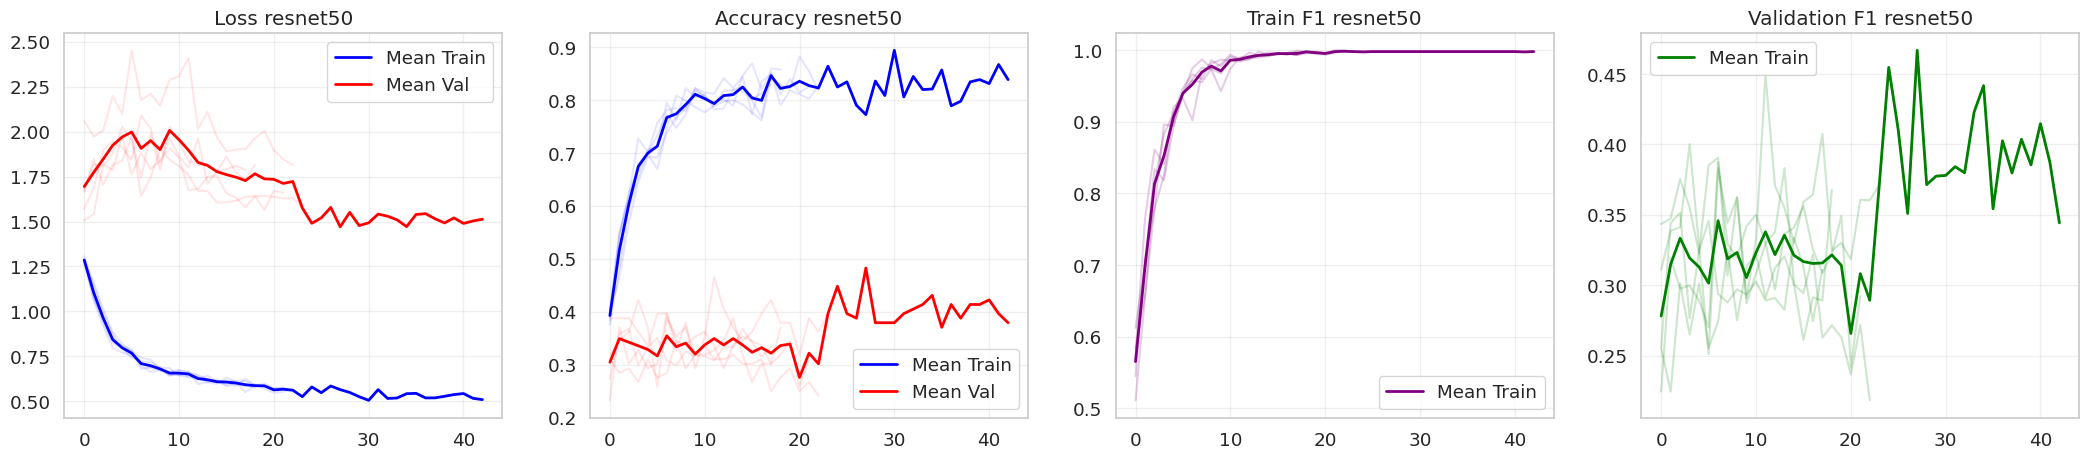


📊 Generating Phase 1 (DL) Confusion Matrix...


AttributeError: 'list' object has no attribute 'ndim'

In [ ]:
# ============================================================
# 8. Main Execution
# ============================================================
if __name__ == "__main__":
    if os.path.exists(Config.CLEAN_LABELS):
        df = pd.read_csv(Config.CLEAN_LABELS)
        
        # 1. TRAIN PHASE 1 (Deep Learning)
        le, histories, dl_oof_f1, oof_targets, dl_oof_preds = train_classifier_kfold(df)
        
        print("\n--- PHASE 1 DIAGNOSTICS ---")
        plot_history_cls(histories, title_suffix=f"{Config.MODEL_NAME}")
        plot_oof_confusion_matrix(oof_targets, dl_oof_preds, le.classes_, title_prefix="Phase 1 (DL)")

        # Viz Feature Space
        viz_model = get_classifier_model(Config.NUM_CLASSES)
        viz_model.load_state_dict(torch.load("classifier_fold0.pth"))
        viz_model = viz_model.to(Config.DEVICE)

        # Temp loader for viz (first 200 images)
        viz_df = df.iloc[:200] 
        viz_ds = MosaicDataset(viz_df, Config.CLEAN_IMG_DIR, Config.CLEAN_MASK_DIR, Config.TRAIN_TIFF_DIR, mode='val', patches_per_image=1, cache_data=False)
        viz_loader = DataLoader(viz_ds, batch_size=Config.BATCH_SIZE, shuffle=False)
        visualize_feature_space(viz_model, viz_loader, le, Config.DEVICE)

        # 2. TRAIN PHASE 2 (Robust Aggregation)
        print("\n--- PHASE 2 OPTIMIZATION ---")

        # A. Extract Features
        train_paths = [os.path.join(Config.CLEAN_IMG_DIR, f) for f in df['sample_index']]
        train_tile_preds = extract_tile_predictions(viz_model, train_paths, Config.TRAIN_TIFF_DIR)

        test_files = sorted([f for f in os.listdir(Config.TEST_IMG_DIR) if f.startswith("img_")])
        test_paths = [os.path.join(Config.TEST_IMG_DIR, f) for f in test_files]
        test_tile_preds = extract_tile_predictions(viz_model, test_paths, Config.TEST_TIFF_DIR)

        # B. Meta Features
        X_train_meta, valid_train = compute_meta_features(train_tile_preds, df['sample_index'].tolist())
        X_test_meta, valid_test = compute_meta_features(test_tile_preds, test_files)

        y_train_aligned = le.transform(df[df['sample_index'].isin(valid_train)]['label'])

        # C. Train Logistic Regression
        lr_oof, lr_test_preds, lr_f1 = train_robust_aggregator(X_train_meta, y_train_aligned, X_test_meta)

        plot_oof_confusion_matrix(y_train_aligned, lr_oof, le.classes_, title_prefix="Phase 2 (Robust)")
        # 3. SUBMISSION
        final_preds_idx = np.argmax(lr_test_preds, axis=1)
        final_labels = le.inverse_transform(final_preds_idx)

        sub_df = pd.DataFrame({
            'sample_index': valid_test, 
            'label': final_labels
        })
        f1_str = f"{lr_f1:.4f}".replace(".", "")
        fname = f"submission_robust_f1_{f1_str}.csv"
        sub_df.to_csv(fname, index=False)
        print(f"✅ Final Submission Saved: {fname}")
    
    else:
        print("❌ Data not found.")


--- PHASE 1 DIAGNOSTICS ---

📊 Plotting History for 5 Folds...


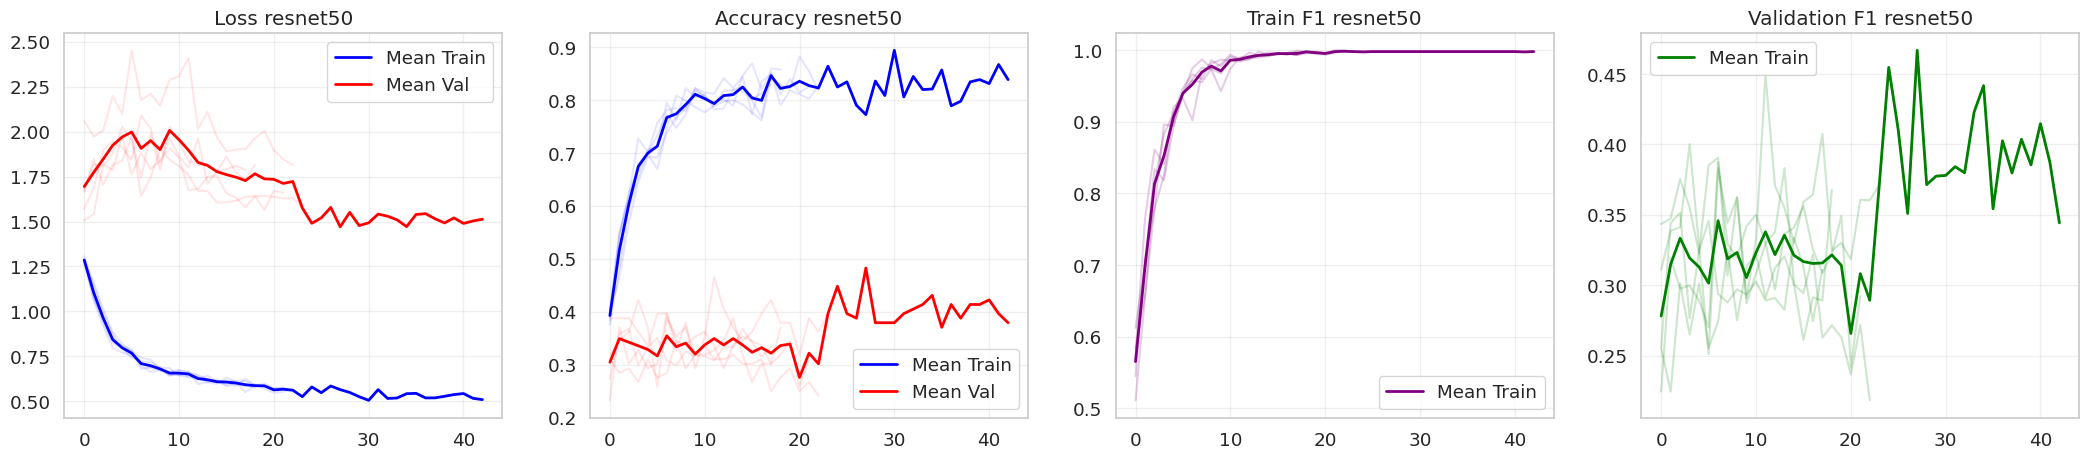


📊 Generating Phase 1 (DL) Confusion Matrix...


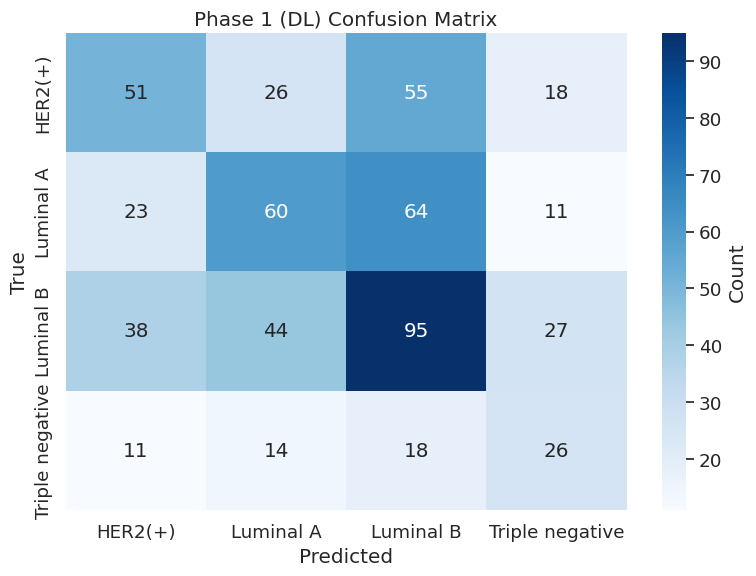


Phase 1 (DL) Classification Report:

                 precision    recall  f1-score   support

        HER2(+)       0.41      0.34      0.37       150
      Luminal A       0.42      0.38      0.40       158
      Luminal B       0.41      0.47      0.44       204
Triple negative       0.32      0.38      0.34        69

       accuracy                           0.40       581
      macro avg       0.39      0.39      0.39       581
   weighted avg       0.40      0.40      0.40       581

   Instantiating resnet50 (4-Channel)...

🎨 Projecting Feature Space (resnet50) with t-SNE...


Extracting Features:   0%|          | 0/13 [00:00<?, ?it/s]

   Computing t-SNE projection...


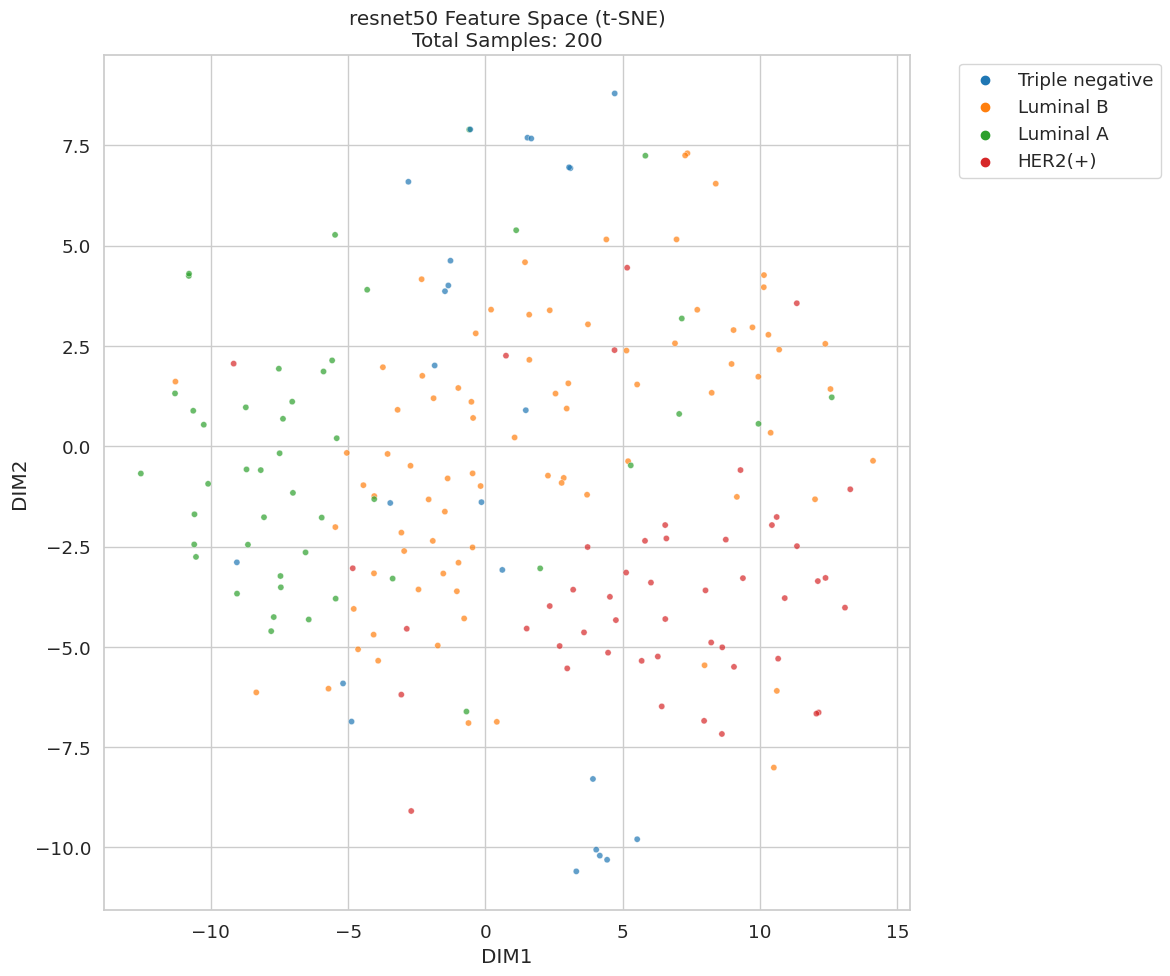


--- PHASE 2 OPTIMIZATION ---
   🔮 Extracting Tile Probabilities from 581 slides...


Tile Inference:   0%|          | 0/581 [00:00<?, ?it/s]

   🔮 Extracting Tile Probabilities from 477 slides...


Tile Inference:   0%|          | 0/477 [00:00<?, ?it/s]

   📊 Computing Meta-Features (Positivity Indices)...
   📊 Computing Meta-Features (Positivity Indices)...

🧠 Training Robust Aggregator (LogisticRegression)...
   Fold 1 F1: 0.3065
   Fold 2 F1: 0.7022
   Fold 3 F1: 0.6687
   Fold 4 F1: 0.6795
   Fold 5 F1: 0.7095
✅ Robust CV Complete. Avg F1: 0.6133

📊 Generating Phase 2 (Robust) Confusion Matrix...


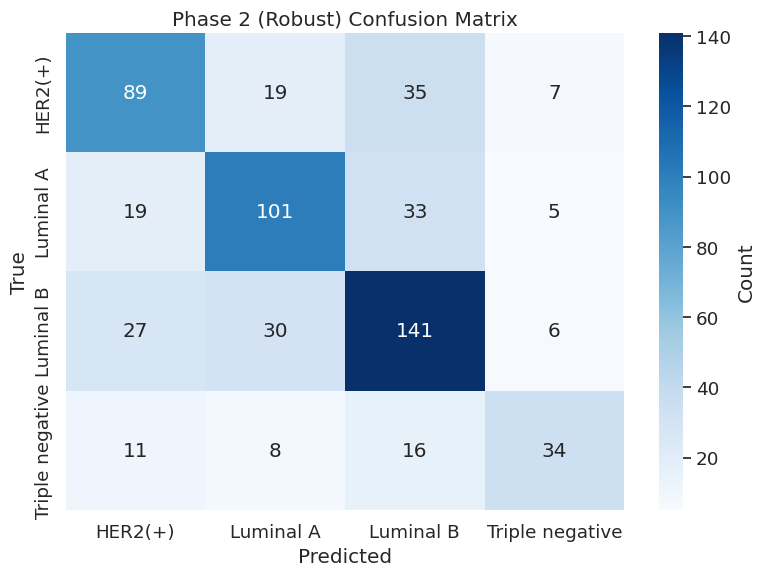


Phase 2 (Robust) Classification Report:

                 precision    recall  f1-score   support

        HER2(+)       0.61      0.59      0.60       150
      Luminal A       0.64      0.64      0.64       158
      Luminal B       0.63      0.69      0.66       204
Triple negative       0.65      0.49      0.56        69

       accuracy                           0.63       581
      macro avg       0.63      0.60      0.61       581
   weighted avg       0.63      0.63      0.63       581



ValueError: Unknown format code 'f' for object of type 'str'